# Assess how in silico ChIP reduces number of motifs called

Sadly need to rerun a few steps because the intermediate files were not saved

In [1]:
###################
## Load packages
###################
suppressPackageStartupMessages({
    library(scran)
    library(scater)
    library(Seurat)
    library(ArchR)
})
source('/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/code/revision/insilico_chip/utils.R')


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .______      
          /   \     |   _ 

In [2]:
###################
## I/O
###################
io = list()
io$basedir = '/rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/'

## Single-cell
io$RNA_sce = file.path(io$basedir,"data/processed/rna/SingleCellExperiment.rds")
io$meta = file.path(io$basedir,"results/atac/archR/qc/sample_metadata_after_qc.txt.gz")

# ArchR vitro
io$archrvitro = file.path("/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/processed/atac/archR")
# ArchR vivo
io$archrvivo = file.path(io$basedir,"data/processed/atac/archR")

# output
io$outdir = file.path("/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood/results/multiome_atlas")
dir.create(io$outdir, recursive=TRUE, showWarnings =FALSE)

In [3]:
meta = fread(io$meta)[pass_rnaQC == T & pass_atacQC == T & doublet_call == F & !sample %in% c('E8.5_CRISPR_T_KO', 'E8.5_CRISPR_T_WT')]
nrow(meta)

[1] 45713

In [4]:
archrvivo = loadArchRProject(io$archrvivo)[meta$cell]
archrvitro = loadArchRProject(io$archrvitro)

Successfully loaded ArchRProject!


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ _____ ,--,__,=##,__   ///
        ,    __==    ___,-,__,--'#'  ==='      `-'    | ##,-/
        -,____,---'       \\####\\________________,--\\_##,/
           ___      .______        ______  __    __  .____

In [5]:
archrvivo


           ___      .______        ______  __    __  .______      
          /   \     |   _  \      /      ||  |  |  | |   _  \     
         /  ^  \    |  |_)  |    |  ,----'|  |__|  | |  |_)  |    
        /  /_\  \   |      /     |  |     |   __   | |      /     
       /  _____  \  |  |\  \\___ |  `----.|  |  |  | |  |\  \\___.
      /__/     \__\ | _| `._____| \______||__|  |__| | _| `._____|
    



class: ArchRProject 
outputDirectory: /rds/project/rds-SDzz0CATGms/users/bt392/atlasses/gastrulation_multiome/data/processed/atac/archR 
samples(11): E7.5_rep1 E7.5_rep2 ... E8.5_CRISPR_T_KO E8.5_CRISPR_T_WT
sampleColData names(1): ArrowFiles
cellColData names(35): Sample TSSEnrichment ... ReadsInPeaks FRIP
numberOfCells(1): 45713
medianTSS(1): 16.355
medianFrags(1): 30489

In [6]:
# Add in vitro peak matrix to vivo ArchR object
vitroPeaks = getPeakSet(archrvitro)

In [8]:
addArchRThreads(24)
archrvivo = addFeatureMatrix(
              input = archrvivo,
              features = vitroPeaks,
              matrixName = "vitroPeakMatrix",
              ceiling = 4,
              binarize = FALSE,
              verbose = TRUE,
              threads = getArchRThreads(),
              parallelParam = NULL,
              force = TRUE,
              logFile = createLogFile("vitroPeakMatrix")
            )

Setting default number of Parallel threads to 24.

ArchR logging to : ArchRLogs/ArchR-vitroPeakMatrix-11ad326dcca7-Date-2024-09-20_Time-09-21-42.log
If there is an issue, please report to github with logFile!

2024-09-20 09:21:44 : Batch Execution w/ safelapply!, 0 mins elapsed.

ArchR logging successful to : ArchRLogs/ArchR-vitroPeakMatrix-11ad326dcca7-Date-2024-09-20_Time-09-21-42.log



In [9]:
addArchRThreads(5)
atac.sce = getMatrixFromProject(archrvivo, useMatrix = 'vitroPeakMatrix')

Setting default number of Parallel threads to 5.

ArchR logging to : ArchRLogs/ArchR-getMatrixFromProject-11ad357e871e2-Date-2024-09-20_Time-09-25-01.log
If there is an issue, please report to github with logFile!

2024-09-20 09:26:01 : Organizing colData, 0.991 mins elapsed.

2024-09-20 09:26:01 : Organizing rowData, 0.996 mins elapsed.

2024-09-20 09:26:01 : Organizing rowRanges, 0.996 mins elapsed.

2024-09-20 09:26:01 : Organizing Assays (1 of 1), 0.996 mins elapsed.

2024-09-20 09:26:30 : Constructing SummarizedExperiment, 1.469 mins elapsed.

2024-09-20 09:27:16 : Finished Matrix Creation, 2.238 mins elapsed.



In [10]:
## High resolution clustering to determine correlations between ATAC and RNA
## Note: I'm not performing any batch correction, Clusters will likely have some form of sample-specificity, but it is unlikely that this will affect downstream results as they will still capture cell-type within those samples as well
# Load SingleCellExperiment
rna.sce <- readRDS(io$RNA_sce)
#rna.sce = rna.sce[,match(meta$cell, colnames(rna.sce))]
# Make sure that samples are consistent
cells <- intersect(colnames(rna.sce),colnames(atac.sce))
rna.sce <- rna.sce[,cells]
atac.sce <- atac.sce[,cells]

In [11]:
rna.sce = logNormCounts(rna.sce)

In [13]:
# RNA dimreduction
decomp <- modelGeneVar(rna.sce, block = rna.sce$sample)
decomp <- decomp[decomp$mean > 0.01,]
hvgs <- decomp[order(decomp$FDR),] %>% head(n=5000) %>% rownames

sce_filt <- rna.sce[hvgs,]
sce_filt <- runPCA(sce_filt, ncomponents = 40, ntop=5000)

In [14]:
# Create Seurat object with PCA 
pca <- reducedDim(sce_filt,"PCA")
counts = matrix(ncol=length(colnames(rna.sce)), nrow=1)
colnames(counts) = colnames(rna.sce)
rownames(counts) = 'x'
seurat = CreateSeuratObject(counts)                
seurat[["pca"]] <- CreateDimReducObject(embeddings = pca, key = "PC_", assay = DefaultAssay(seurat))

In [15]:
# high clustering resolution instead of metacells
library(future)
plan("multisession", workers = 6)
seurat <- FindNeighbors(seurat, dims = 1:40)
seurat <- FindClusters(seurat, resolution = 20)

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 45707
Number of edges: 1531911

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.7126
Number of communities: 222
Elapsed time: 5 seconds


In [16]:
clusters = as.data.table(seurat@meta.data, keep.rownames=T) %>% .[,c('rn', 'seurat_clusters')] %>% setnames(c('cell', 'cluster'))

In [17]:
library(BiocParallel)
BPPARAM = MulticoreParam(24)

In [18]:
# Pseudobulk by clusters
rna.pb = aggregateAcrossCells(rna.sce, id=clusters$cluster, BPPARAM = BPPARAM)
atac.pb = aggregateAcrossCells(atac.sce, use.assay.type = 'vitroPeakMatrix', id=clusters$cluster, BPPARAM = BPPARAM)

In [19]:
assay(rna.pb,"logcounts") <- log(1e6*(sweep(assay(rna.pb),2,colSums(assay(rna.pb),na.rm=T),"/"))+1) 
assay(atac.pb,"logcounts") <- log(1e6*(sweep(assay(atac.pb),2,colSums(assay(atac.pb),na.rm=T),"/"))+1)

# Cisbp

In [ ]:
## Get motif matches for example motifs in peaks 
## Adapted from: https://rdrr.io/github/GreenleafLab/ArchR/src/R/AnnotationPeaks.R
# Load motifs
library(motifmatchr)
library(chromVARmotifs)

data("mouse_pwms_v2")
motifs <- mouse_pwms_v2
obj <- ArchR:::.summarizeChromVARMotifs(motifs)
motifs <- obj$motifs
motifSummary <- obj$motifSummary
names(motifs) = gsub( 'Tcfap', 'tfap', names(motifs))

In [358]:
# Subset RNA & ATAC only to a few peaks & genes that have been identified by in silico ChIP
silicoChIP = readRDS(file.path(io$outdir, 'vitro_peaks_silicoChIP_cisbp.rds'))

In [414]:
EOMES = silicoChIP@assays@data$VirtualChipScores[,'EOMES']
EOMES = EOMES[abs(EOMES)>0]

In [415]:
gene_peak = function(gene, peak){
    tmp = data.table(
                    gene = gene,
                    peak = peak,
                    gene_value = as.vector(logcounts(rna.pb[gene,])),
                    peak_value = as.vector(atac.pb[peak,]@assays@data$logcounts)
                    )
    return(tmp)
}  

In [416]:
eomes = gene_peak('Eomes', names(EOMES[order(-EOMES)][1]))
tbx4 = gene_peak('Tbx4', names(EOMES[order(-EOMES)][1]))

In [417]:
colors = RColorBrewer::brewer.pal(name = 'Set3', n = length(c('Eomes', 'Other', paste0('Tbx', 1:10))))
names(colors) = c('Eomes', 'Other', paste0('Tbx', 1:10))

In [418]:
p1 = ggplot(rbind(eomes, tbx4), aes(gene_value, peak_value, color = gene)) + 
    geom_point() +
    geom_smooth(method = 'lm') + 
    scale_x_continuous(expand = c(0,0)) + 
    scale_y_continuous(expand = c(0,0)) + 
    scale_color_manual(values = colors, name = 'TF') + 
    xlab('Gene Expression') + ylab('Peak Accessibility') + 
    ggtitle(names(EOMES[order(-EOMES)][1])) + 
    theme_bw() +
    theme(legend.position = 'none')

In [419]:
# Find positions
peak = names(EOMES[order(-EOMES)][1])
vitroPeaks$peakname = sprintf('%s:%s-%s', seqnames(vitroPeaks), start(vitroPeaks), end(vitroPeaks))
motifmatcher_position.se <-  motifmatchr::matchMotifs(pwms = motifs, 
                                        subject = vitroPeaks[vitroPeaks$peakname == peak], 
                                        genome = "mm10", 
                                        out = 'positions',
                                        p.cutoff = 5e-05,
                                        w = 7) 

matches.plot = mclapply(1:length(motifmatcher_position.se), function(x){
    tmp = motifmatcher_position.se[x]
    if(length(tmp) > 0){
         return(as.data.table(tmp) %>% .[,name:=str_split(group_name, '_') %>% map_chr(1)])
    }
}, mc.cores = 24) %>% rbindlist()

matches.plot = matches.plot[,name_clean := ifelse(name %in% c('Eomes', paste0('Tbx', 1:12)), name, 'other')]


In [420]:
p2 = ggplot(matches.plot, aes(start, score)) + 
   # geom_point() +
    geom_segment(aes(x = start, y = score, xend = end, yend = score, colour = name_clean), linewidth = 2) + 
    ggrepel::geom_text_repel(data = matches.plot[name %in% c('Eomes', 'Tbx4')], 
                             aes(x = start + (end-start)/2, label = name),
                             box.padding = 1) + 
    scale_color_manual(values = colors, name = 'TF') + 
    ylim(0, max(matches.plot$score)) + 
    xlab('position') + ylab('motif score') + 
    ggtitle('Motif Score') + 
    theme_bw()  +
    theme(legend.position = 'none')
    

In [421]:
silico_score = silicoChIP@assays@data$VirtualChipScores[peak,]

In [422]:
matches.plot$silico_score = silico_score[match(str_to_upper(matches.plot$name), names(silico_score))]

In [423]:
p3 = ggplot(matches.plot, aes(start, silico_score)) + 
   # geom_point() +
    geom_segment(aes(x = start, y = silico_score, xend = end, yend = silico_score, colour = name_clean), linewidth = 2) + 
    ggrepel::geom_text_repel(data = matches.plot[name %in% c('Eomes', 'Tbx4')], 
                             aes(x = start + (end-start)/2, label = name),
                             box.padding = 1) + 
    scale_color_manual(values = colors, name = 'TF') + 
    geom_hline(yintercept = 0.2, color = 'red', linetype = 'longdash') + 
    geom_hline(yintercept = 0, color = 'black') + 
    scale_y_continuous(limits = c(min(matches.plot$silico_score), max(matches.plot$silico_score)), expand = c(0,0.05)) + 
    xlab('position') + ylab('in silico ChIP score') + 
    ggtitle('In-silico ChIP score') + 
    theme_bw() +
    theme(legend.position = 'none')

In [424]:
options(repr.plot.width = 20, repr.plot.height = 4)
p11 = ggarrange(p1, p2, p3, get_legend(p3 + theme(legend.position = 'right')), widths = c(0.3,0.5,0.5, 0.1),  align = 'hv', nrow = 1)

Warning message:
“Removed 20 rows containing missing values (`geom_segment()`).”
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 20 rows containing missing values (`geom_segment()`).”
Warning message:
“Graphs cannot be vertically aligned unless the axis parameter is set. Placing graphs unaligned.”
Warning message:
“Graphs cannot be horizontally aligned unless the axis parameter is set. Placing graphs unaligned.”


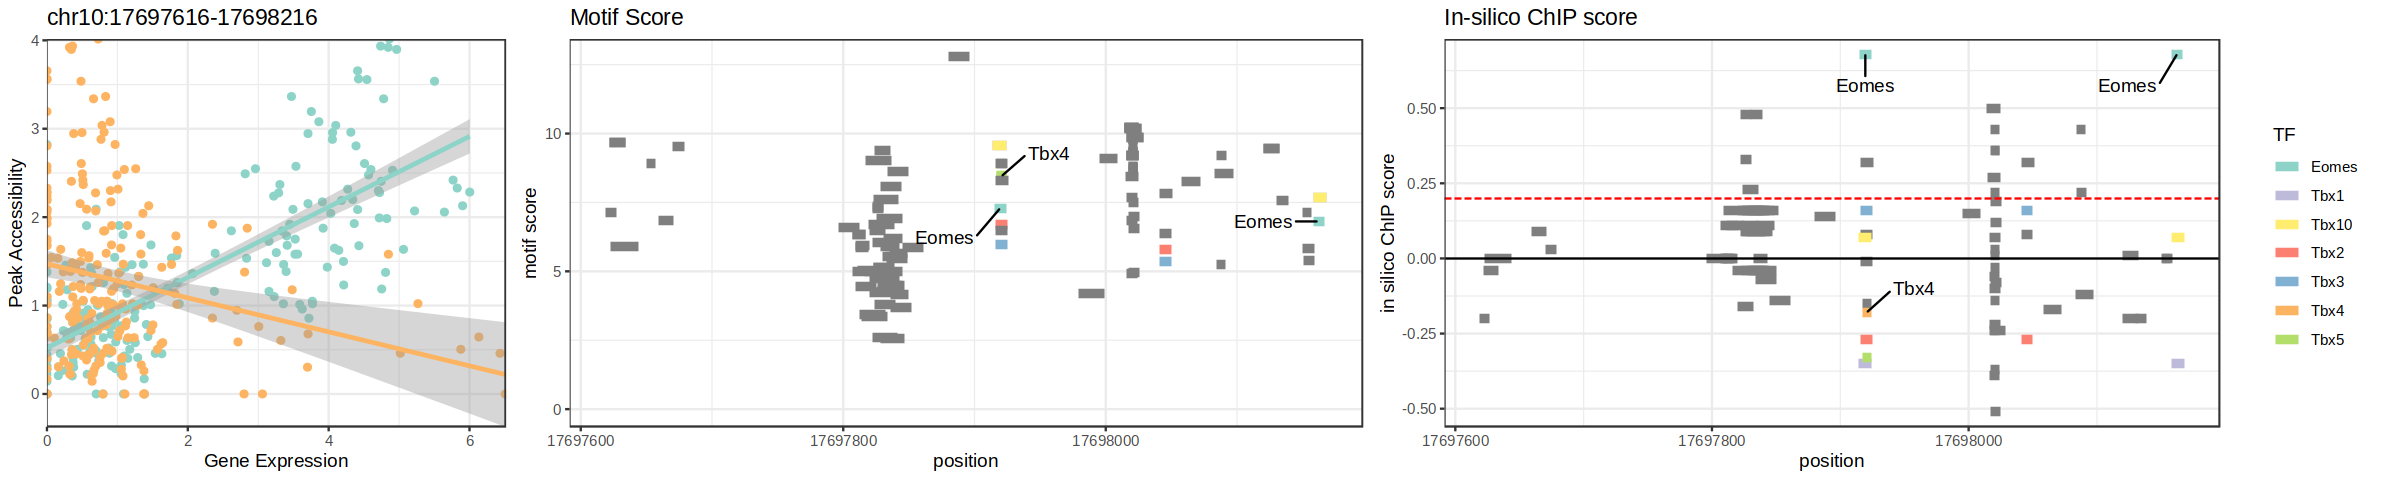

In [425]:
p4

In [426]:
TBX4 = silicoChIP@assays@data$VirtualChipScores[,'TBX4']
TBX4 = TBX4[abs(TBX4)>0]

In [427]:
eomes = gene_peak('Eomes', names(TBX4[order(-TBX4)][1]))
tbx4 = gene_peak('Tbx4', names(TBX4[order(-TBX4)][1]))

In [428]:
colors = RColorBrewer::brewer.pal(name = 'Set3', n = length(c('Eomes', 'Other', paste0('Tbx', 1:10))))
names(colors) = c('Eomes', 'Other', paste0('Tbx', 1:10))

In [440]:
p4 = ggplot(rbind(eomes, tbx4), aes(gene_value, peak_value, color = gene)) + 
    geom_point() +
    geom_smooth(method = 'lm') + 
    scale_x_continuous(expand = c(0,0)) + 
    scale_y_continuous(expand = c(0,0)) + 
    scale_color_manual(values = colors, name = 'TF') + 
    xlab('Gene Expression') + ylab('Peak Accessibility') + 
    ggtitle(names(TBX4[order(-TBX4)][1])) + 
    theme_bw()  +
    theme(legend.position = 'none')

In [430]:
# Find positions
peak = names(TBX4[order(-TBX4)][1])
vitroPeaks$peakname = sprintf('%s:%s-%s', seqnames(vitroPeaks), start(vitroPeaks), end(vitroPeaks))
motifmatcher_position.se <-  motifmatchr::matchMotifs(pwms = motifs, 
                                        subject = vitroPeaks[vitroPeaks$peakname == peak], 
                                        genome = "mm10", 
                                        out = 'positions',
                                        p.cutoff = 5e-05,
                                        w = 7) 

matches.plot = mclapply(1:length(motifmatcher_position.se), function(x){
    tmp = motifmatcher_position.se[x]
    if(length(tmp) > 0){
         return(as.data.table(tmp) %>% .[,name:=str_split(group_name, '_') %>% map_chr(1)])
    }
}, mc.cores = 24) %>% rbindlist()

matches.plot = matches.plot[,name_clean := ifelse(name %in% c('Eomes', paste0('Tbx', 1:12)), name, 'other')]


In [431]:
p5 = ggplot(matches.plot, aes(start, score)) + 
   # geom_point() +
    geom_segment(aes(x = start, y = score, xend = end, yend = score, colour = name_clean), linewidth = 2) + 
    ggrepel::geom_text_repel(data = matches.plot[name %in% c('Eomes', 'Tbx4')], 
                             aes(x = start + (end-start)/2, label = name),
                             box.padding = 1) + 
    scale_color_manual(values = colors, name = 'TF') + 
    ylim(0, max(matches.plot$score)) + 
    xlab('position') + ylab('motif score') + 
    ggtitle('Motif Score') + 
    theme_bw()  +
    theme(legend.position = 'none')
    

In [432]:
silico_score = silicoChIP@assays@data$VirtualChipScores[peak,]

In [433]:
matches.plot$silico_score = silico_score[match(str_to_upper(matches.plot$name), names(silico_score))]

In [434]:
p6 = ggplot(matches.plot, aes(start, silico_score)) + 
   # geom_point() +
    geom_segment(aes(x = start, y = silico_score, xend = end, yend = silico_score, colour = name_clean), linewidth = 2) + 
    ggrepel::geom_text_repel(data = matches.plot[name %in% c('Eomes', 'Tbx4')], 
                             aes(x = start + (end-start)/2, label = name),
                             box.padding = 1) + 
    scale_color_manual(values = colors, name = 'TF') + 
    geom_hline(yintercept = 0.2, color = 'red', linetype = 'longdash') + 
    geom_hline(yintercept = 0, color = 'black') + 
    scale_y_continuous(limits = c(min(matches.plot$silico_score), max(matches.plot$silico_score)), expand = c(0,0.05)) + 
    xlab('position') + ylab('in silico ChIP score') + 
    ggtitle('In-silico ChIP score') + 
    theme_bw() +
    theme(legend.position = 'none')

In [441]:
options(repr.plot.width = 20, repr.plot.height = 4)
p21 = ggarrange(p4, p5, p6, NULL, widths = c(0.3,0.5,0.5, 0.1),  align = 'hv', nrow = 1)

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 15 rows containing missing values (`geom_segment()`).”


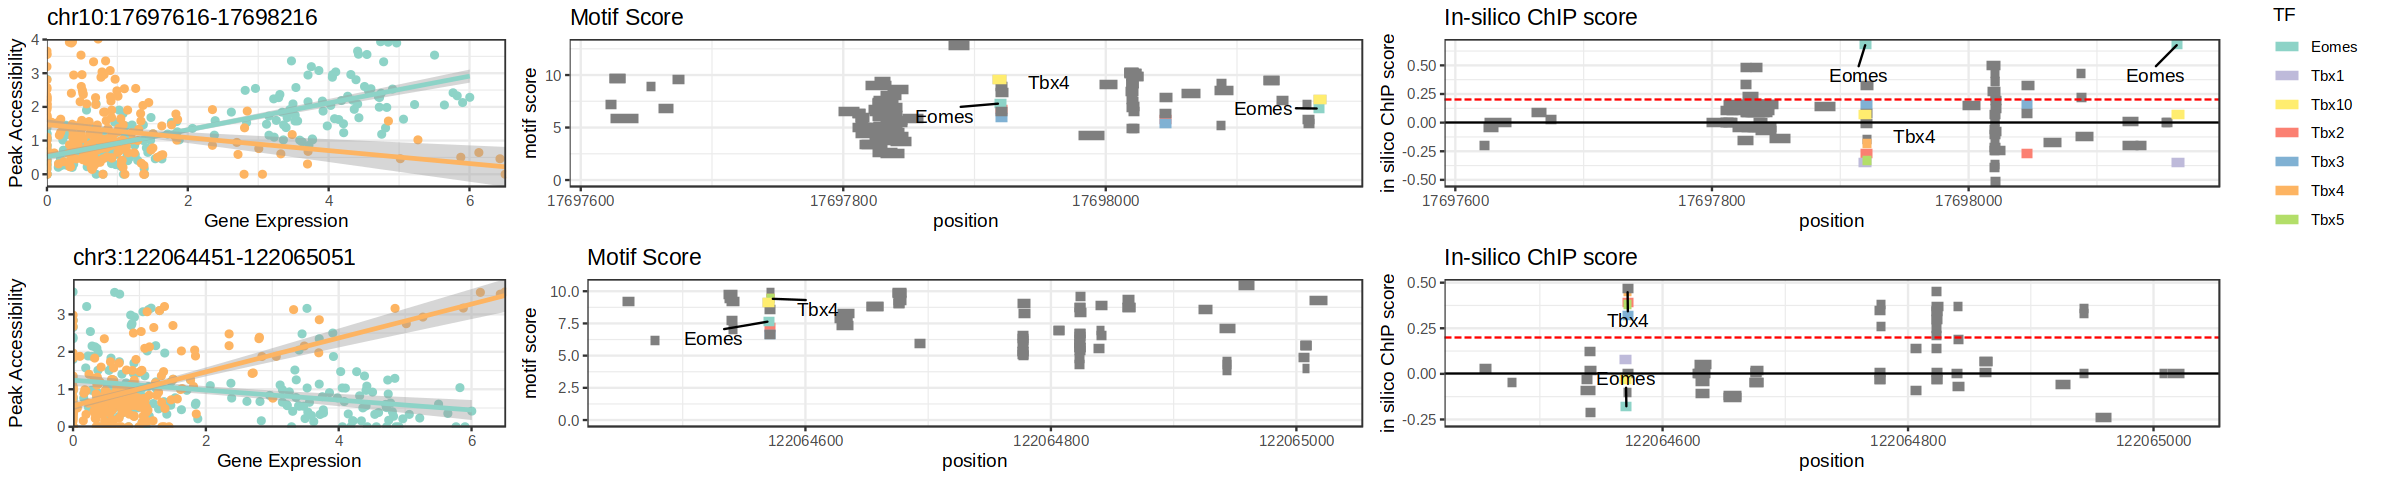

In [442]:
ggarrange(p11, p21, ncol = 1)

Warning message:
“Removed 20 rows containing missing values (`geom_segment()`).”
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 20 rows containing missing values (`geom_segment()`).”
Warning message:
“Graphs cannot be vertically aligned unless the axis parameter is set. Placing graphs unaligned.”
Warning message:
“Graphs cannot be horizontally aligned unless the axis parameter is set. Placing graphs unaligned.”
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 15 rows containing missing values (`geom_segment()`).”


$`1`

$`2`

attr(,"class")
[1] "list"      "ggarrange"

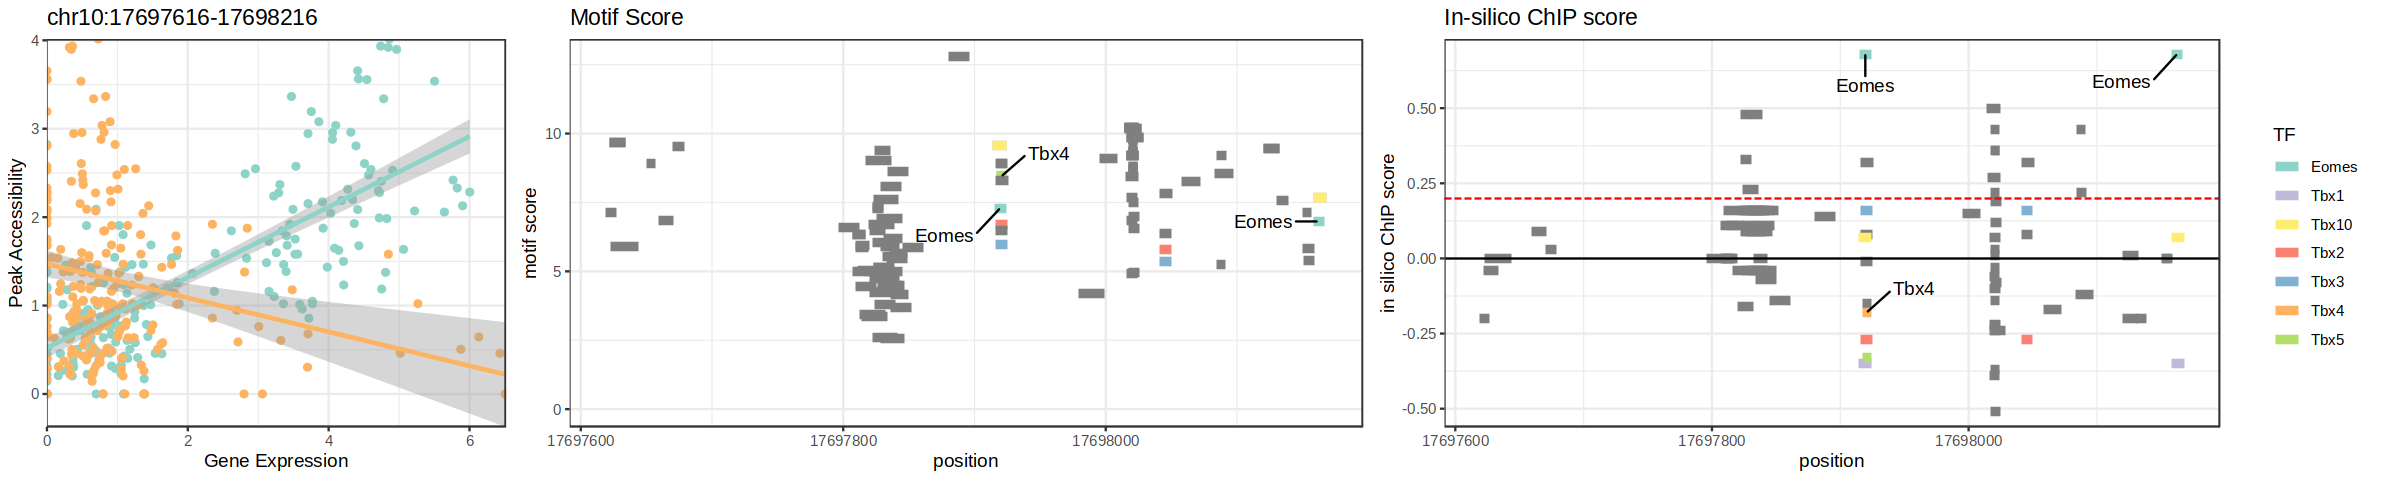

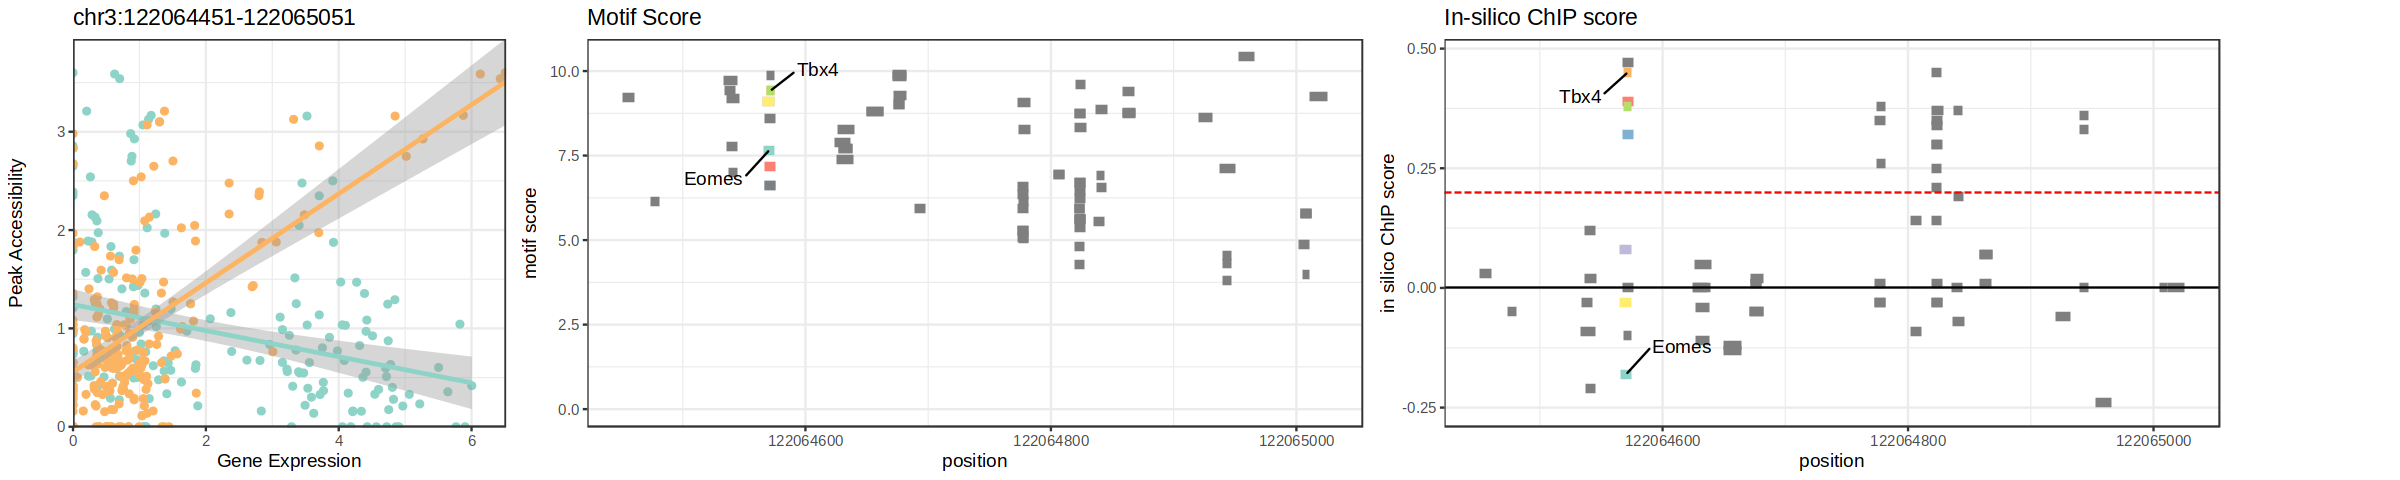

In [449]:
ggarrange(p1, p2, p3, get_legend(p3 + theme(legend.position = 'right')), p4, p5, p6, NULL, ncol = 4, widths = c(0.3,0.5,0.5, 0.1),  align = 'hv')

In [451]:
io$outdir = file.path('/rds/project/rds-SDzz0CATGms/users/bt392/09_Eomes_invitro_blood', '/results/thesis/')

ggsave(file.path(paste0(io$outdir, 'insilicochip.pdf')), 
       plot = ggarrange(p11, p21, ncol = 1),
       width = 340, 
       height = 150, 
       units = "mm")